In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression


In [2]:
from sklearn.linear_model import LogisticRegression

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score,recall_score, f1_score,confusion_matrix, classification_report,roc_auc_score, roc_curve)

In [4]:
print("All libraries imported successfully!")

All libraries imported successfully!


In [5]:
hotel_df = pd.read_csv('hotel_bookings.csv')

In [6]:
print(f"Total Records : {hotel_df.shape[0]:,}")

Total Records : 119,390


In [7]:
print(f"Total Features: {hotel_df.shape[1]}")

Total Features: 32


In [8]:
hotel_df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [9]:
hotel_df.shape

(119390, 32)

# Data Preprocessing

In [10]:
hotel_df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [11]:
hotel_df.shape

(119390, 32)

### Duplicate Rows Check

In [12]:
print("=" * 45)
print("DUPLICATE ROWS CHECK")
print("=" * 45)

# Total duplicates count
duplicates = hotel_df.duplicated().sum()
total      = len(hotel_df)

print(f"Total Rows        : {total:,}")
print(f"Duplicate Rows    : {duplicates:,}")
print(f"Duplicate %       : {duplicates/total*100:.2f}%")
print(f"Unique Rows       : {total - duplicates:,}")

if duplicates > 0:
    print(f"\n⚠️  {duplicates:,} duplicate rows found — need to remove!")
else:
    print("\n No duplicates found!")

DUPLICATE ROWS CHECK
Total Rows        : 119,390
Duplicate Rows    : 31,994
Duplicate %       : 26.80%
Unique Rows       : 87,396

⚠️  31,994 duplicate rows found — need to remove!


## Duplicate Row Remove 

In [13]:
before = len(hotel_df)
hotel_df = hotel_df.drop_duplicates()
after  = len(hotel_df)

print(f"Before : {before:,} rows")
print(f"After  : {after:,} rows")
print(f"Removed: {before - after:,} duplicate rows")

Before : 119,390 rows
After  : 87,396 rows
Removed: 31,994 duplicate rows


In [14]:
hotel_df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
119385    False
119386    False
119387    False
119388    False
119389    False
Length: 87396, dtype: bool

In [15]:
hotel_df.duplicated().sum()

np.int64(0)

### Null Values check

In [16]:
hotel_df.isnull().sum()

hotel                                 0
is_canceled                           0
lead_time                             0
arrival_date_year                     0
arrival_date_month                    0
arrival_date_week_number              0
arrival_date_day_of_month             0
stays_in_weekend_nights               0
stays_in_week_nights                  0
adults                                0
children                              4
babies                                0
meal                                  0
country                             452
market_segment                        0
distribution_channel                  0
is_repeated_guest                     0
previous_cancellations                0
previous_bookings_not_canceled        0
reserved_room_type                    0
assigned_room_type                    0
booking_changes                       0
deposit_type                          0
agent                             12193
company                           82137


In [17]:
print("=" * 45)
print("HANDLING MISSING VALUES")
print("=" * 45)

# 1. Drop agent and company — too many nulls
hotel_df = hotel_df.drop(columns=['agent', 'company'])
print(" Dropped  : agent (12,193 nulls)")
print(" Dropped  : company (82,137 nulls)")

# 2. Fill children nulls with 0
hotel_df['children'] = hotel_df['children'].fillna(0)
print(" Filled   : children → 0")

# 3. Fill country nulls with mode
hotel_df['country'] = hotel_df['country'].fillna(
                      hotel_df['country'].mode()[0])
print(" Filled   : country → mode value")

# Verify — no nulls remaining
print()
print("=" * 45)
print("VERIFY — NULL VALUES AFTER FIX")
print("=" * 45)
remaining = hotel_df.isnull().sum().sum()
print(f"Remaining null values : {remaining}")

if remaining == 0:
    print(" All missing values handled!")
else:
    print(f" {remaining} nulls still remaining!")

HANDLING MISSING VALUES
 Dropped  : agent (12,193 nulls)
 Dropped  : company (82,137 nulls)
 Filled   : children → 0
 Filled   : country → mode value

VERIFY — NULL VALUES AFTER FIX
Remaining null values : 0
 All missing values handled!


In [18]:
hotel_df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces       0
total_of_special_requests   

### Data Leakage Columns Drop

In [19]:
print("=" * 45)
print("CORRELATION WITH TARGET (is_canceled)")
print("=" * 45)


numeric_df = hotel_df.select_dtypes(include='number')
correlation = numeric_df.corr()['is_canceled'].abs().sort_values(ascending=False)

print(correlation)

CORRELATION WITH TARGET (is_canceled)
is_canceled                       1.000000
lead_time                         0.184806
required_car_parking_spaces       0.184206
adr                               0.127986
total_of_special_requests         0.120545
booking_changes                   0.093644
is_repeated_guest                 0.089643
arrival_date_year                 0.088030
stays_in_week_nights              0.082928
adults                            0.081816
children                          0.067369
stays_in_weekend_nights           0.060191
previous_bookings_not_canceled    0.052154
previous_cancellations            0.051468
babies                            0.020543
arrival_date_day_of_month         0.005328
days_in_waiting_list              0.004464
arrival_date_week_number          0.001443
Name: is_canceled, dtype: float64


### Outlier Treatment

OUTLIER TREATMENT — adr COLUMN
BEFORE treatment:
  Min adr : -6.38
  Max adr : 5400.00
  Mean adr: 106.34


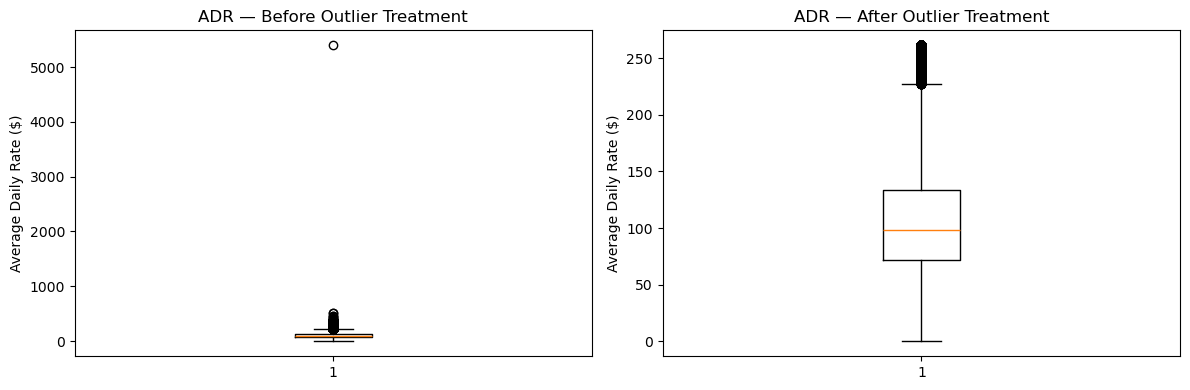


AFTER treatment:
  Min adr : 0.00
  Max adr : 261.41
  Mean adr: 105.95

 Outliers capped at 99th percentile: 261.41


In [20]:
print("=" * 45)
print("OUTLIER TREATMENT — adr COLUMN")
print("=" * 45)

# Before
print("BEFORE treatment:")
print(f"  Min adr : {hotel_df['adr'].min():.2f}")
print(f"  Max adr : {hotel_df['adr'].max():.2f}")
print(f"  Mean adr: {hotel_df['adr'].mean():.2f}")

# Visualise before
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.boxplot(hotel_df['adr'])
plt.title('ADR — Before Outlier Treatment')
plt.ylabel('Average Daily Rate ($)')

# Fix — cap at 99th percentile
adr_cap = hotel_df['adr'].quantile(0.99)
hotel_df['adr'] = hotel_df['adr'].clip(lower=0, upper=adr_cap)

# Visualise after
plt.subplot(1, 2, 2)
plt.boxplot(hotel_df['adr'])
plt.title('ADR — After Outlier Treatment')
plt.ylabel('Average Daily Rate ($)')

plt.tight_layout()
plt.savefig('outlier_treatment.png', dpi=150, bbox_inches='tight')
plt.show()

# After
print("\nAFTER treatment:")
print(f"  Min adr : {hotel_df['adr'].min():.2f}")
print(f"  Max adr : {hotel_df['adr'].max():.2f}")
print(f"  Mean adr: {hotel_df['adr'].mean():.2f}")
print(f"\n Outliers capped at 99th percentile: {adr_cap:.2f}")

### Label Encoding

In [21]:
print("=" * 45)
print("LABEL ENCODING — TEXT TO NUMBERS")
print("=" * 45)

from sklearn.preprocessing import LabelEncoder

# Find all text (object) columns
cat_cols = hotel_df.select_dtypes(include='object').columns.tolist()

print(f"Text columns found : {len(cat_cols)}")
print(f"Columns            : {cat_cols}")
print()

# Encode each column
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    hotel_df[col] = le.fit_transform(hotel_df[col].astype(str))
    le_dict[col]  = le
    print(f" Encoded : {col}")

print()
print("=" * 45)
print("ENCODING VERIFICATION")
print("=" * 45)
print(f"Text columns remaining : "
      f"{hotel_df.select_dtypes(include='object').shape[1]}")
print(f"All numeric now        : "
      f"{hotel_df.select_dtypes(include='number').shape[1]} columns")
print()
print(" Label Encoding complete!")
print()

# Show sample encoded values
print("=" * 45)
print("SAMPLE — ENCODED VALUES")
print("=" * 45)
print(hotel_df[['hotel','meal','deposit_type','customer_type']].head())

LABEL ENCODING — TEXT TO NUMBERS
Text columns found : 12
Columns            : ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']

 Encoded : hotel
 Encoded : arrival_date_month
 Encoded : meal
 Encoded : country
 Encoded : market_segment
 Encoded : distribution_channel
 Encoded : reserved_room_type
 Encoded : assigned_room_type
 Encoded : deposit_type
 Encoded : customer_type
 Encoded : reservation_status
 Encoded : reservation_status_date

ENCODING VERIFICATION
Text columns remaining : 0
All numeric now        : 30 columns

 Label Encoding complete!

SAMPLE — ENCODED VALUES
   hotel  meal  deposit_type  customer_type
0      1     0             0              2
1      1     0             0              2
2      1     0             0              2
3      1     0             0              2
4      1     0             0  

### Define Features (X) and Target (y)

In [22]:
print("=" * 45)
print("FEATURES (X) AND TARGET (y) SPLIT")
print("=" * 45)

X = hotel_df.drop('is_canceled', axis=1)
y = hotel_df['is_canceled']

print(f"Features (X) shape : {X.shape}")
print(f"Target   (y) shape : {y.shape}")
print()

# Feature columns show 
print("=" * 45)
print("FEATURE COLUMNS (X)")
print("=" * 45)
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2}. {col}")

print()
print("=" * 45)
print("TARGET COLUMN (y) — is_canceled")
print("=" * 45)
print(f"  Not Cancelled (0) : {(y==0).sum():,}")
print(f"  Cancelled     (1) : {(y==1).sum():,}")
print(f"  Cancel Rate       : {y.mean()*100:.1f}%")
print()
print(" X and y split complete!")

FEATURES (X) AND TARGET (y) SPLIT
Features (X) shape : (87396, 29)
Target   (y) shape : (87396,)

FEATURE COLUMNS (X)
   1. hotel
   2. lead_time
   3. arrival_date_year
   4. arrival_date_month
   5. arrival_date_week_number
   6. arrival_date_day_of_month
   7. stays_in_weekend_nights
   8. stays_in_week_nights
   9. adults
  10. children
  11. babies
  12. meal
  13. country
  14. market_segment
  15. distribution_channel
  16. is_repeated_guest
  17. previous_cancellations
  18. previous_bookings_not_canceled
  19. reserved_room_type
  20. assigned_room_type
  21. booking_changes
  22. deposit_type
  23. days_in_waiting_list
  24. customer_type
  25. adr
  26. required_car_parking_spaces
  27. total_of_special_requests
  28. reservation_status
  29. reservation_status_date

TARGET COLUMN (y) — is_canceled
  Not Cancelled (0) : 63,371
  Cancelled     (1) : 24,025
  Cancel Rate       : 27.5%

 X and y split complete!


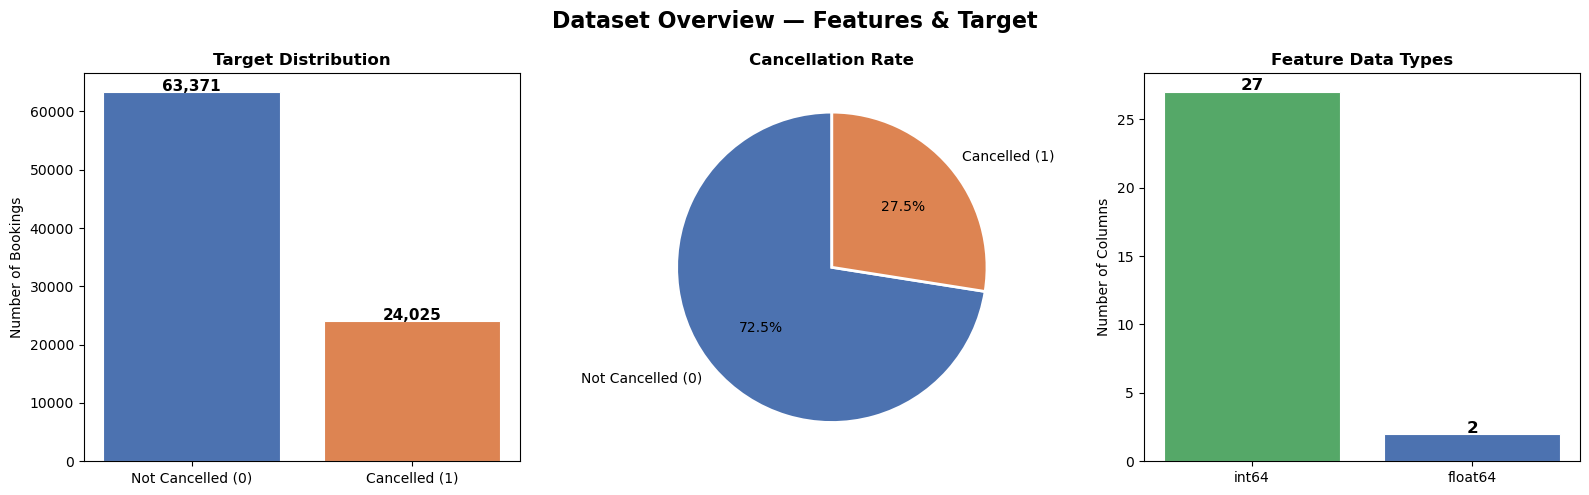

Charts saved: xy_split_overview.png


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Dataset Overview — Features & Target',
             fontsize=16, fontweight='bold')

# ── Chart 1: Target Distribution (Bar) ───────────────────
labels = ['Not Cancelled (0)', 'Cancelled (1)']
counts = [( y==0).sum(), (y==1).sum()]
colors = ['#4C72B0', '#DD8452']

bars = axes[0].bar(labels, counts, color=colors,
                   edgecolor='white', linewidth=0.8)
axes[0].set_title('Target Distribution',
                  fontweight='bold', fontsize=12)
axes[0].set_ylabel('Number of Bookings')
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 200,
                 f'{count:,}',
                 ha='center', fontweight='bold', fontsize=11)

# ── Chart 2: Target Distribution (Pie) ───────────────────
axes[1].pie(counts,
            labels=labels,
            autopct='%1.1f%%',
            colors=colors,
            startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Cancellation Rate',
                  fontweight='bold', fontsize=12)

# ── Chart 3: Feature Data Types ──────────────────────────
dtype_counts = X.dtypes.value_counts()
axes[2].bar(dtype_counts.index.astype(str),
            dtype_counts.values,
            color=['#55A868','#4C72B0'],
            edgecolor='white', linewidth=0.8)
axes[2].set_title('Feature Data Types',
                  fontweight='bold', fontsize=12)
axes[2].set_ylabel('Number of Columns')
for i, v in enumerate(dtype_counts.values):
    axes[2].text(i, v + 0.1, str(v),
                 ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('xy_split_overview.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Charts saved: xy_split_overview.png")

### Train / Test Split

In [24]:
print("=" * 45)
print("TRAIN / TEST SPLIT")
print("=" * 45)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,      # 20% test
    random_state = 42,        # reproducibility
    stratify     = y          # class balance maintain
)

print(f"Total dataset    : {len(X):,} rows")
print()
print(f"Training set     : {X_train.shape[0]:,} rows "
      f"({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set         : {X_test.shape[0]:,} rows  "
      f"({X_test.shape[0]/len(X)*100:.0f}%)")
print()
print(f"Training features: {X_train.shape[1]} columns")
print(f"Test features    : {X_test.shape[1]} columns")
print()

# Class balance check
print("=" * 45)
print("CLASS BALANCE CHECK")
print("=" * 45)
print(f"Train — Not Cancelled: {(y_train==0).sum():,} "
      f"({(y_train==0).mean()*100:.1f}%)")
print(f"Train — Cancelled    : {(y_train==1).sum():,} "
      f"({(y_train==1).mean()*100:.1f}%)")
print()
print(f"Test  — Not Cancelled: {(y_test==0).sum():,}  "
      f"({(y_test==0).mean()*100:.1f}%)")
print(f"Test  — Cancelled    : {(y_test==1).sum():,}  "
      f"({(y_test==1).mean()*100:.1f}%)")
print()
print("Train/Test split complete!")

TRAIN / TEST SPLIT
Total dataset    : 87,396 rows

Training set     : 69,916 rows (80%)
Test set         : 17,480 rows  (20%)

Training features: 29 columns
Test features    : 29 columns

CLASS BALANCE CHECK
Train — Not Cancelled: 50,696 (72.5%)
Train — Cancelled    : 19,220 (27.5%)

Test  — Not Cancelled: 12,675  (72.5%)
Test  — Cancelled    : 4,805  (27.5%)

Train/Test split complete!


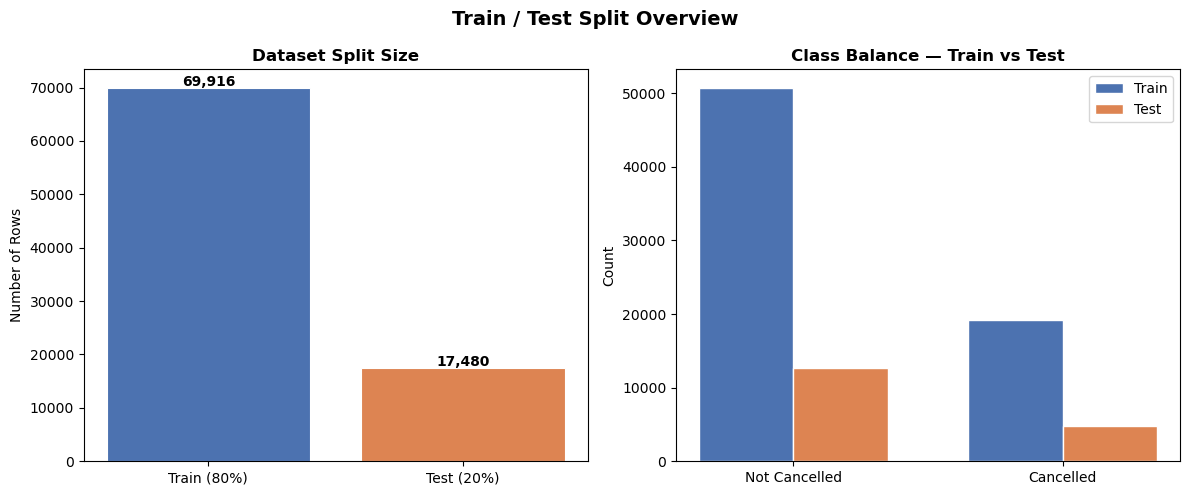

Chart saved: train_test_split.png


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Train / Test Split Overview',
             fontsize=14, fontweight='bold')

# Chart 1 — Split Size
split_labels = ['Train (80%)', 'Test (20%)']
split_sizes  = [X_train.shape[0], X_test.shape[0]]
split_colors = ['#4C72B0', '#DD8452']

axes[0].bar(split_labels, split_sizes,
            color=split_colors,
            edgecolor='white', linewidth=0.8)
axes[0].set_title('Dataset Split Size',
                  fontweight='bold')
axes[0].set_ylabel('Number of Rows')
for i, v in enumerate(split_sizes):
    axes[0].text(i, v + 300, f'{v:,}',
                 ha='center', fontweight='bold')

# Chart 2 — Class Balance
x      = np.arange(2)
width  = 0.35
train_counts = [(y_train==0).sum(), (y_train==1).sum()]
test_counts  = [(y_test==0).sum(),  (y_test==1).sum()]

axes[1].bar(x - width/2, train_counts,
            width, label='Train',
            color='#4C72B0', edgecolor='white')
axes[1].bar(x + width/2, test_counts,
            width, label='Test',
            color='#DD8452', edgecolor='white')
axes[1].set_title('Class Balance — Train vs Test',
                  fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Not Cancelled', 'Cancelled'])
axes[1].legend()

plt.tight_layout()
plt.savefig('train_test_split.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: train_test_split.png")

### Feature Scaling

In [26]:
print("=" * 45)
print("FEATURE SCALING — STANDARD SCALER")
print("=" * 45)
print()
print("Why scaling is needed:")
print("  lead_time range : 0 to 737")
print("  adr range       : 0 to 261")
print("  adults range    : 0 to 10")
print("  → Different scales confuse the model!")
print()

from sklearn.preprocessing import StandardScaler

# IMPORTANT: fit_transform on TRAIN only
# transform on TEST only — prevent data leakage!
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("After StandardScaler:")
print(f"  Training mean : {X_train_scaled.mean():.4f} (should be ~0)")
print(f"  Training std  : {X_train_scaled.std():.4f}  (should be ~1)")
print(f"  Test mean     : {X_test_scaled.mean():.4f}")
print(f"  Test std      : {X_test_scaled.std():.4f}")
print()
print(f"  X_train_scaled shape : {X_train_scaled.shape}")
print(f"  X_test_scaled shape  : {X_test_scaled.shape}")
print()
print("Feature Scaling complete!")

FEATURE SCALING — STANDARD SCALER

Why scaling is needed:
  lead_time range : 0 to 737
  adr range       : 0 to 261
  adults range    : 0 to 10
  → Different scales confuse the model!

After StandardScaler:
  Training mean : 0.0000 (should be ~0)
  Training std  : 1.0000  (should be ~1)
  Test mean     : 0.0010
  Test std      : 1.0051

  X_train_scaled shape : (69916, 29)
  X_test_scaled shape  : (17480, 29)

Feature Scaling complete!


### Application of the appropriate learning algorithm 


In [27]:
# ── Algorithm Justification — Code ───────────────────────
print("=" * 45)
print("ALGORITHM — LOGISTIC REGRESSION")
print("=" * 45)
print()
print("Algorithm    : Logistic Regression")
print("Type         : Supervised Learning")
print("Task         : Binary Classification")
print("Target       : is_canceled (0 or 1)")
print()
print("Key Parameters:")
print("  solver     : lbfgs (efficient for large data)")
print("  max_iter   : 1000  (ensures convergence)")
print("  C          : 1.0   (regularisation strength)")
print("  penalty    : L2    (prevents overfitting)")
print()
print("Why Logistic Regression?")
print("  1. Binary target variable (0 or 1)")
print("  2. Industry standard baseline model")
print("  3. Highly interpretable coefficients")
print("  4. Handles 87,396 rows efficiently")
print("  5. L2 regularisation — no overfitting")

ALGORITHM — LOGISTIC REGRESSION

Algorithm    : Logistic Regression
Type         : Supervised Learning
Task         : Binary Classification
Target       : is_canceled (0 or 1)

Key Parameters:
  solver     : lbfgs (efficient for large data)
  max_iter   : 1000  (ensures convergence)
  C          : 1.0   (regularisation strength)
  penalty    : L2    (prevents overfitting)

Why Logistic Regression?
  1. Binary target variable (0 or 1)
  2. Industry standard baseline model
  3. Highly interpretable coefficients
  4. Handles 87,396 rows efficiently
  5. L2 regularisation — no overfitting


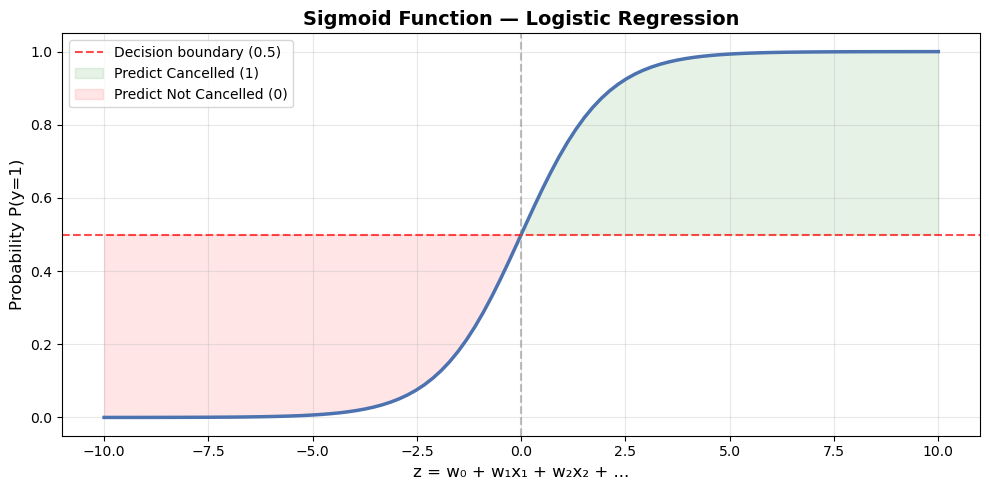

Sigmoid plot saved!


In [28]:
# Sigmoid Function Plot 

z = np.linspace(-10, 10, 100)
sigmoid = 1 / (1 + np.exp(-z))

plt.figure(figsize=(10, 5))
plt.plot(z, sigmoid, color='#4C72B0', linewidth=2.5)
plt.axhline(y=0.5, color='red', linestyle='--',
            alpha=0.7, label='Decision boundary (0.5)')
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.fill_between(z, sigmoid, 0.5,
                 where=(sigmoid > 0.5),
                 alpha=0.1, color='green',
                 label='Predict Cancelled (1)')
plt.fill_between(z, sigmoid, 0.5,
                 where=(sigmoid < 0.5),
                 alpha=0.1, color='red',
                 label='Predict Not Cancelled (0)')
plt.xlabel('z = w₀ + w₁x₁ + w₂x₂ + ...', fontsize=12)
plt.ylabel('Probability P(y=1)', fontsize=12)
plt.title('Sigmoid Function — Logistic Regression',
          fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('sigmoid_function.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Sigmoid plot saved!")